In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['short_name', 'age', 'nationality_name', 'league_name', 
        'club_name', 'overall', 'potential', 'value_eur', 
        'wage_eur', 'pace', 'shooting', 'passing', 
        'dribbling', 'defending', 'physic', 'fifa_version']  # ← added this!

df = pd.read_csv("C:/Users/besto/ds-journey/male_players (legacy).csv", 
                 usecols=cols,
                 low_memory=False)

# Filter FIFA 23 only!
df = df[df['fifa_version'] == 23]

print("✅ FIFA 23 players loaded!")
print("Shape:", df.shape)

✅ FIFA 23 players loaded!
Shape: (18533, 16)


In [2]:
print(df.isnull().sum())

fifa_version           0
short_name             0
overall                0
potential              0
value_eur             89
wage_eur              78
age                    0
league_name           78
club_name             78
nationality_name       0
pace                2066
shooting            2066
passing             2066
dribbling           2066
defending           2066
physic              2066
dtype: int64


In [3]:
stat_cols = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

for col in stat_cols:
    df[col] = df[col].fillna(df[col].median())

df = df.dropna(subset=['overall', 'potential', 'age', 'league_name'])

print("✅ Data cleaned!")
print("Remaining players:", len(df))

✅ Data cleaned!
Remaining players: 18455


In [4]:
df['gem_score'] = df['potential'] - df['overall']
df['youth_bonus'] = df['age'].apply(lambda x: 5 if x <= 23 else 0)
df['final_gem_score'] = df['gem_score'] + df['youth_bonus']

print("✅ Gem scores calculated!")

✅ Gem scores calculated!


In [5]:
hidden_gems = df[
    (df['age'] <= 23) &           # Young
    (df['overall'] >= 60) &       # Some base quality
    (df['overall'] <= 75) &       # Under the radar
    (df['final_gem_score'] >= 8)  # Big potential gap
].sort_values('final_gem_score', ascending=False)

print(f"🌟 Hidden gems found: {len(hidden_gems)}")
print(hidden_gems[['short_name', 'age', 'overall', 'potential', 
                    'final_gem_score', 'league_name', 'club_name']].head(10))

🌟 Hidden gems found: 4813
          short_name  age  overall  potential  final_gem_score  \
158333   C. Riquelme   18       60         83               28   
158328     G. Restes   17       60         83               28   
157785     L. Harris   17       61         84               28   
158321  F. Chiarodia   17       60         83               28   
158306     A. Devine   17       60         83               28   
158489     L. Ulrich   17       60         83               28   
158391       G. Kuol   17       60         82               27   
157516      T. Nakai   18       61         83               27   
156776   S. Raebiger   17       62         84               27   
158433     J. Bahoya   17       60         82               27   

             league_name               club_name  
158333  Primera Division                 Everton  
158328           Ligue 1                Toulouse  
157785    Premier League                  Fulham  
158321        Bundesliga           Werder B

C:\Users\besto\AppData\Local\Temp\ipykernel_13620\2309395459.py:9: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\besto\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


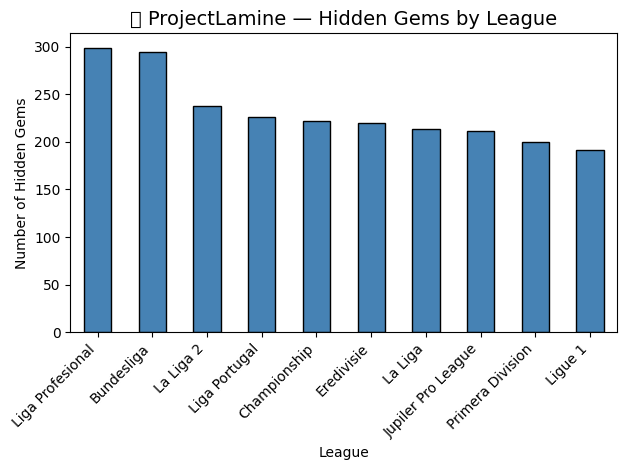

In [6]:
# Top 10 leagues with most hidden gems
top_leagues = hidden_gems['league_name'].value_counts().head(10)

top_leagues.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('🌟 ProjectLamine — Hidden Gems by League', fontsize=14)
plt.xlabel('League')
plt.ylabel('Number of Hidden Gems')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\besto\AppData\Local\Temp\ipykernel_13620\2182968675.py:10: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\besto\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


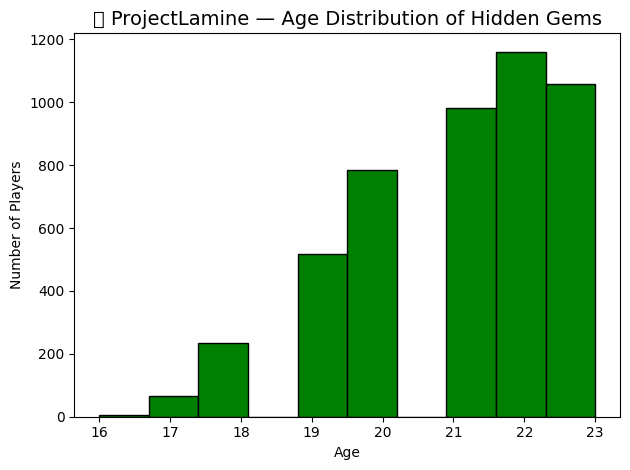

In [7]:
hidden_gems['age'].plot(
    kind='hist', 
    bins=10, 
    color='green', 
    edgecolor='black'
)
plt.title('🌟 ProjectLamine — Age Distribution of Hidden Gems', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()

C:\Users\besto\AppData\Local\Temp\ipykernel_13620\2639622871.py:17: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\besto\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


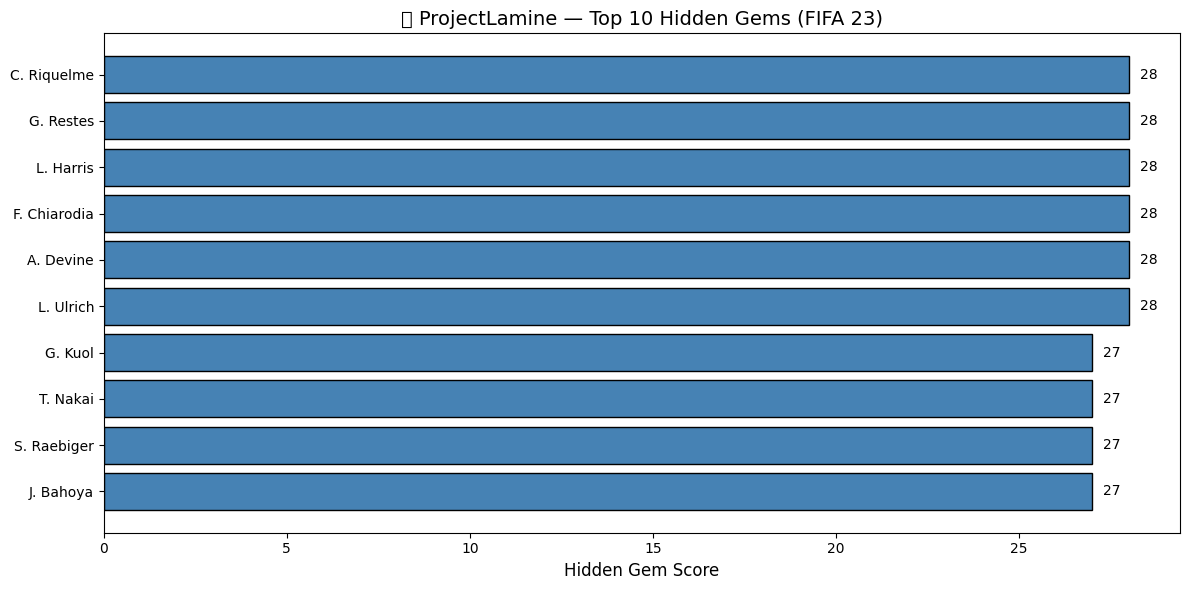

In [8]:
top10 = hidden_gems.head(10).copy()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(top10['short_name'], top10['final_gem_score'], 
               color='steelblue', edgecolor='black')

ax.set_xlabel('Hidden Gem Score', fontsize=12)
ax.set_title('⚽ ProjectLamine — Top 10 Hidden Gems (FIFA 23)', fontsize=14)
ax.invert_yaxis()

# Add score labels on bars
for bar, score in zip(bars, top10['final_gem_score']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{score}', va='center', fontsize=10)

plt.tight_layout()
plt.show()